In [1]:
import scanpy as sc
import os
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
os.getcwd()

'/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type/0531_no_Basophil'

# with other unknown
整体流程

```text
第一步：生成 X_basic_celltype_proportion.csv 和 y_sample_label_numeric.csv
        ↓
中间这一步：生成 X_pseudobulk_marker.csv
        ↓
再拼接生成 X_combined_basic_plus_pseudobulk.csv
        ↓
训练验证 LogisticRegression
        ↓
生成 unknown 特征 / 预测 unknown

In [2]:
def get_mean_expression(sub_adata, genes):
    if len(genes) == 0:
        return pd.Series(dtype=float)
    sub = sub_adata[:, genes]
    X = sub.X
    mean_expr = np.asarray(X.mean(axis=0)).ravel() if sparse.issparse(X) else np.asarray(X.mean(axis=0)).ravel()
    return pd.Series(mean_expr, index=genes)

# Plaque stability / vulnerability related marker sets.
# Feature names are kept in human gene symbols; mouse data are mapped to these symbols before feature building.
PLAQUE_STABILITY_MARKERS_HUMAN = {
    "Macrophage": [
        "C1QA", "C1QB", "CD68", "AIF1", "LGALS3", "CD163",
        "APOE", "LPL", "TREM2", "SPP1", "IL1B", "TNF", "CCL2", "NLRP3",
        "MMP9", "MMP12", "CTSS", "CTSK"
    ],
    "Smooth muscle cell": [
        "ACTA2", "MYH11", "TAGLN", "CNN1", "MYOCD",
        "COL1A1", "COL1A2", "COL3A1", "ELN", "DCN", "LUM",
        "VCAN", "FN1", "MMP2", "MGP", "RUNX2", "SOX9", "KLF4", "SPP1"
    ],
    "Endothelial cell": [
        "PECAM1", "VWF", "CLDN5", "CD34", "EDN1", "NOS3",
        "VCAM1", "ICAM1", "SELE", "PLVAP", "KDR", "FLT1", "ANGPT2", "CXCL12"
    ],
    "Fibroblast": [
        "LUM", "DCN", "COL1A1", "COL1A2", "COL3A1", "ELN", "FBLN1",
        "FN1", "POSTN", "MMP2", "MMP14", "TIMP1", "TIMP3"
    ],
    "T cell": [
        "CD3D", "CD3E", "IL7R", "CCR7", "CCL5", "NKG7", "GZMB", "PRF1", "IFNG", "CXCR3"
    ]
}

# Explicit one-to-one mouse -> human symbols for the selected marker panel.
# Avoid using gene.capitalize() here: that is a naming heuristic, not an ortholog table.
MOUSE_TO_HUMAN_ORTHOLOG = {
    "C1qa": "C1QA", "C1qb": "C1QB", "Cd68": "CD68", "Aif1": "AIF1",
    "Lgals3": "LGALS3", "Cd163": "CD163", "Apoe": "APOE", "Lpl": "LPL",
    "Trem2": "TREM2", "Spp1": "SPP1", "Il1b": "IL1B", "Tnf": "TNF",
    "Ccl2": "CCL2", "Nlrp3": "NLRP3", "Mmp9": "MMP9", "Mmp12": "MMP12",
    "Ctss": "CTSS", "Ctsk": "CTSK", "Acta2": "ACTA2", "Myh11": "MYH11",
    "Tagln": "TAGLN", "Cnn1": "CNN1", "Myocd": "MYOCD", "Col1a1": "COL1A1",
    "Col1a2": "COL1A2", "Col3a1": "COL3A1", "Eln": "ELN", "Dcn": "DCN",
    "Lum": "LUM", "Vcan": "VCAN", "Fn1": "FN1", "Mmp2": "MMP2",
    "Mgp": "MGP", "Runx2": "RUNX2", "Sox9": "SOX9", "Klf4": "KLF4",
    "Pecam1": "PECAM1", "Vwf": "VWF", "Cldn5": "CLDN5", "Cd34": "CD34",
    "Edn1": "EDN1", "Nos3": "NOS3", "Vcam1": "VCAM1", "Icam1": "ICAM1",
    "Sele": "SELE", "Plvap": "PLVAP", "Kdr": "KDR", "Flt1": "FLT1",
    "Angpt2": "ANGPT2", "Cxcl12": "CXCL12", "Fbln1": "FBLN1", "Postn": "POSTN",
    "Mmp14": "MMP14", "Timp1": "TIMP1", "Timp3": "TIMP3", "Cd3d": "CD3D",
    "Cd3e": "CD3E", "Il7r": "IL7R", "Ccr7": "CCR7", "Ccl5": "CCL5",
    "Nkg7": "NKG7", "Gzmb": "GZMB", "Prf1": "PRF1", "Ifng": "IFNG",
    "Cxcr3": "CXCR3"
}

marker_dict = PLAQUE_STABILITY_MARKERS_HUMAN


def standardize_gene_names_for_marker_features(adata_in, mouse_to_human=None):
    """Map mouse-style marker symbols to human symbols so train/predict pseudobulk columns match."""
    if mouse_to_human is None:
        mouse_to_human = MOUSE_TO_HUMAN_ORTHOLOG
    old_names = pd.Index(adata_in.var_names.astype(str))
    new_names = pd.Index([mouse_to_human.get(g, g) for g in old_names])
    n_renamed = int((old_names != new_names).sum())
    if n_renamed > 0:
        print(f"Mapped {n_renamed} mouse-style marker gene names to human symbols for feature alignment.")
        adata_in.var_names = new_names.astype(str)
        adata_in.var_names_make_unique()
    return adata_in


def build_pseudobulk_features(adata_in, marker_dict, sample_col, celltype_col, include_ncells=False):
    all_genes = set(adata_in.var_names)
    filtered_marker_dict, missing_marker_report = {}, {}
    for ct, genes in marker_dict.items():
        present = [g for g in genes if g in all_genes]
        missing = [g for g in genes if g not in all_genes]
        filtered_marker_dict[ct] = present
        missing_marker_report[ct] = missing
    print("\n===== marker presence check =====")
    for ct in marker_dict:
        print(f"{ct}:")
        print("  present:", filtered_marker_dict[ct])
        print("  missing:", missing_marker_report[ct])
    filtered_marker_dict = {ct: genes for ct, genes in filtered_marker_dict.items() if len(genes) > 0}
    all_celltypes = set(adata_in.obs[celltype_col].astype(str).unique())
    print("\n===== cell types in adata =====")
    print(sorted(list(all_celltypes))[:50])
    valid_celltypes = [ct for ct in filtered_marker_dict if ct in all_celltypes]
    invalid_celltypes = [ct for ct in filtered_marker_dict if ct not in all_celltypes]
    if len(invalid_celltypes) > 0:
        print("\n这些 marker_dict 里的 cell type 不在 adata.obs 里，请检查命名：")
        print(invalid_celltypes)
    filtered_marker_dict = {ct: filtered_marker_dict[ct] for ct in valid_celltypes}
    if len(filtered_marker_dict) == 0:
        raise ValueError("没有任何有效的 cell type + marker 组合。")
    feature_rows = []
    sample_ids = adata_in.obs[sample_col].astype(str).unique().tolist()
    for sample_id in sample_ids:
        sample_mask = adata_in.obs[sample_col].astype(str) == str(sample_id)
        adata_sample = adata_in[sample_mask].copy()
        row_dict = {"sample": sample_id}
        for ct, genes in filtered_marker_dict.items():
            ct_mask = adata_sample.obs[celltype_col].astype(str) == ct
            n_cells = int(ct_mask.sum())
            if n_cells == 0:
                for g in genes:
                    row_dict[f"pb__{ct}__{g}"] = 0.0
                if include_ncells:
                    row_dict[f"pb_ncells__{ct}"] = 0
                continue
            adata_sub = adata_sample[ct_mask].copy()
            mean_expr = get_mean_expression(adata_sub, genes)
            for g in genes:
                row_dict[f"pb__{ct}__{g}"] = float(mean_expr[g])
            if include_ncells:
                row_dict[f"pb_ncells__{ct}"] = n_cells
        feature_rows.append(row_dict)
    X_pb = pd.DataFrame(feature_rows).set_index("sample").sort_index()
    return X_pb


## Plaque stability marker rationale

这里的 pseudobulk marker 已从单纯细胞身份 marker 扩展为斑块稳定性/易损性相关状态 marker：巨噬细胞炎症、泡沫化与基质降解；平滑肌细胞收缩型、ECM/纤维帽与表型转换；内皮激活和血管新生；成纤维细胞 ECM 重塑。跨物种预测时，mouse-style marker gene symbols 会被映射到 human symbols，保证训练和预测的 `pb__celltype__gene` 列名一致。


## prepare input

In [3]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse

# ========================= 参数 =========================
H5AD_PATH = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_allhuman/scPoli_concat_level3_marker_all_metadata.h5ad"
OUT_DIR = "./output_marker/"
os.makedirs(OUT_DIR, exist_ok=True)

SAMPLE_COL = "sample"
# CELLTYPE_COL = "cell_type_level1"
CELLTYPE_COL = "cell_type_level1_corrected"##应该用cell_type_level1_corrected
LABEL_RAW_COL = "Plaque_type"
LABEL_COL = "Plaque_type_clean"

TRAIN_X_BASIC_PATH = f"{OUT_DIR}/X_basic_celltype_proportion.csv"
TRAIN_X_PB_PATH = f"{OUT_DIR}/X_pseudobulk_marker.csv"
TRAIN_X_COMBINED_PATH = f"{OUT_DIR}/X_combined_basic_plus_pseudobulk.csv"
Y_LABEL_PATH = f"{OUT_DIR}/y_sample_label.csv"
Y_NUM_PATH = f"{OUT_DIR}/y_sample_label_numeric.csv"

OUT_X_BASIC_UNKNOWN = f"{OUT_DIR}/X_basic_unknown_celltype_proportion.csv"
OUT_X_PB_UNKNOWN = f"{OUT_DIR}/X_pseudobulk_marker_unknown.csv"
OUT_X_UNKNOWN_COMBINED = f"{OUT_DIR}/X_unknown_combined_basic_plus_pseudobulk.csv"

marker_dict = PLAQUE_STABILITY_MARKERS_HUMAN



# ========================= 1. 读取和预处理 h5ad =========================
print("Reading h5ad...")
adata = sc.read_h5ad(H5AD_PATH)
adata = adata[adata.obs[CELLTYPE_COL] != "unknown"].copy()
adata.var["original_feature_id"] = adata.var_names.astype(str)
adata.var_names = adata.var["original_gene_names"].astype(str)
adata.var_names_make_unique()
adata = standardize_gene_names_for_marker_features(adata)
adata.obs[LABEL_COL] = adata.obs[LABEL_RAW_COL].astype(str).str.strip().str.lower()

adata.obs[LABEL_COL] = adata.obs[LABEL_COL].replace({
    "nan": "unknown",
    "na": "unknown",
    "none": "unknown",
    "": "unknown",
    "unknown": "unknown",
    "Unknown": "unknown",
})
adata.obs[LABEL_COL] = adata.obs[LABEL_COL].fillna("unknown")

required_cols = [SAMPLE_COL, CELLTYPE_COL, LABEL_COL]
missing_cols = [c for c in required_cols if c not in adata.obs.columns]
if len(missing_cols) > 0:
    raise ValueError(f"adata.obs 缺少这些列: {missing_cols}")

print("adata shape after filtering unknown cell type:", adata.shape)
print("sample label distribution:")
print(adata.obs[LABEL_COL].value_counts(dropna=False))

# ========================= 2. 生成训练集 X_basic 和 y =========================
print("\nBuilding training X_basic and y...")
obs = adata.obs[[SAMPLE_COL, CELLTYPE_COL, LABEL_COL]].copy()
obs = obs.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])
train_obs = obs[obs[LABEL_COL].isin(["stable", "unstable"])].copy()

print("训练细胞数:", train_obs.shape[0])
print("训练标签分布:")
print(train_obs[LABEL_COL].value_counts())

cell_count = pd.crosstab(train_obs[SAMPLE_COL], train_obs[CELLTYPE_COL])
cell_prop = cell_count.div(cell_count.sum(axis=1), axis=0)
cell_prop.columns = [f"prop__{c}" for c in cell_prop.columns]

sample_label = train_obs[[SAMPLE_COL, LABEL_COL]].drop_duplicates().groupby(SAMPLE_COL, observed=True)[LABEL_COL].agg(lambda x: x.iloc[0] if len(set(x)) == 1 else "conflict")
conflict_samples = sample_label[sample_label == "conflict"].index.tolist()
if len(conflict_samples) > 0:
    print("仍然冲突的 sample:", conflict_samples[:20])
    raise ValueError("还有 sample 存在多个标签，请进一步检查。")

sample_label = sample_label.rename("label")
common_samples = cell_prop.index.intersection(sample_label.index)
X_basic = cell_prop.loc[common_samples].copy().sort_index()
y = sample_label.loc[common_samples].copy().sort_index()
y_num = y.map({"stable": 0, "unstable": 1})

print("X_basic shape:", X_basic.shape)
print("y shape:", y_num.shape)
print("y label counts:")
print(y.value_counts())

X_basic.to_csv(TRAIN_X_BASIC_PATH)
y.to_csv(Y_LABEL_PATH, header=True)
y_num.to_csv(Y_NUM_PATH, header=True)
print(f"Saved: {TRAIN_X_BASIC_PATH}")
print(f"Saved: {Y_LABEL_PATH}")
print(f"Saved: {Y_NUM_PATH}")

# ========================= 3. 生成训练集 X_pseudobulk 和 X_combined =========================
print("\nBuilding training X_pseudobulk...")
adata_train = adata[adata.obs[LABEL_COL].isin(["stable", "unstable"])].copy()
X_pb = build_pseudobulk_features(adata_train, marker_dict, SAMPLE_COL, CELLTYPE_COL)
X_pb.to_csv(TRAIN_X_PB_PATH)
print("X_pb shape:", X_pb.shape)
print(f"Saved: {TRAIN_X_PB_PATH}")

common_samples = X_basic.index.intersection(X_pb.index)
X_combined = pd.concat([X_basic.loc[common_samples], X_pb.loc[common_samples]], axis=1)
X_combined.to_csv(TRAIN_X_COMBINED_PATH)
print("X_combined shape:", X_combined.shape)
print(f"Saved: {TRAIN_X_COMBINED_PATH}")

# ========================= 4. 生成 unknown 样本 X_basic_unknown =========================
print("\nBuilding unknown features...")
adata_unknown = adata[adata.obs[LABEL_COL].isin(["unknown"])].copy()
print("adata_unknown shape:", adata_unknown.shape)
print("unknown label counts:")
print(adata_unknown.obs[LABEL_COL].value_counts())

if adata_unknown.n_obs == 0:
    raise ValueError("没有找到标签为 unknown 的样本。")

obs_unknown = adata_unknown.obs[[SAMPLE_COL, CELLTYPE_COL, LABEL_COL]].copy()
obs_unknown = obs_unknown.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])
cell_count_unknown = pd.crosstab(obs_unknown[SAMPLE_COL], obs_unknown[CELLTYPE_COL])
cell_prop_unknown = cell_count_unknown.div(cell_count_unknown.sum(axis=1), axis=0)
cell_prop_unknown.columns = [f"prop__{c}" for c in cell_prop_unknown.columns]

X_basic_unknown = cell_prop_unknown.copy()
X_basic_unknown = X_basic_unknown.reindex(columns=X_basic.columns, fill_value=0)
X_basic_unknown.to_csv(OUT_X_BASIC_UNKNOWN)
print("X_basic_unknown shape:", X_basic_unknown.shape)
print(f"Saved: {OUT_X_BASIC_UNKNOWN}")

# ========================= 5. 生成 unknown 样本 X_pseudobulk 和 X_unknown_combined =========================
print("\nBuilding unknown X_pseudobulk...")
X_pb_unknown = build_pseudobulk_features(adata_unknown, marker_dict, SAMPLE_COL, CELLTYPE_COL)
X_pb_unknown = X_pb_unknown.reindex(columns=X_pb.columns, fill_value=0)
X_pb_unknown.to_csv(OUT_X_PB_UNKNOWN)
print("X_pb_unknown shape:", X_pb_unknown.shape)
print(f"Saved: {OUT_X_PB_UNKNOWN}")

common_unknown_samples = X_basic_unknown.index.intersection(X_pb_unknown.index)
X_unknown_combined = pd.concat([X_basic_unknown.loc[common_unknown_samples], X_pb_unknown.loc[common_unknown_samples]], axis=1)
X_unknown_combined = X_unknown_combined.reindex(columns=X_combined.columns, fill_value=0)
X_unknown_combined.to_csv(OUT_X_UNKNOWN_COMBINED)
print("X_unknown_combined shape:", X_unknown_combined.shape)
print(f"Saved: {OUT_X_UNKNOWN_COMBINED}")

print("\nDone.")


Reading h5ad...
adata shape after filtering unknown cell type: (1004247, 28868)
sample label distribution:
Plaque_type_clean
unknown     790610
unstable    152880
stable       60757
Name: count, dtype: int64

Building training X_basic and y...
训练细胞数: 213637
训练标签分布:
Plaque_type_clean
unstable    152880
stable       60757
Name: count, dtype: int64
X_basic shape: (23, 13)
y shape: (23,)
y label counts:
label
unstable    16
stable       7
Name: count, dtype: int64
Saved: ./output_marker//X_basic_celltype_proportion.csv
Saved: ./output_marker//y_sample_label.csv
Saved: ./output_marker//y_sample_label_numeric.csv

Building training X_pseudobulk...

===== marker presence check =====
Macrophage:
  present: ['C1QA', 'C1QB', 'CD68', 'AIF1', 'LGALS3', 'CD163', 'APOE', 'LPL', 'TREM2', 'SPP1', 'IL1B', 'TNF', 'CCL2', 'NLRP3', 'MMP9', 'MMP12', 'CTSS', 'CTSK']
  missing: []
Smooth muscle cell:
  present: ['ACTA2', 'MYH11', 'TAGLN', 'CNN1', 'MYOCD', 'COL1A1', 'COL1A2', 'COL3A1', 'ELN', 'DCN', 'LUM', 'V

# train

In [ ]:
# 这个是把有标签的数据全部拿来训练 没有标签的数据拿来预测-----没办法看预测准确性
# import pandas as pd
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression

# # 训练集
# X_train = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
# y_train = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# # 训练最终模型
# final_model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("clf", LogisticRegression(
#         penalty="l2",
#         C=1.0,
#         class_weight="balanced",
#         max_iter=1000,
#         random_state=42
#     ))
# ])

# final_model.fit(X_train, y_train)

# # unknown 特征
# X_unknown = pd.read_csv("./output/X_unknown_combined_basic_plus_pseudobulk.csv", index_col=0)
# X_unknown = X_unknown.reindex(columns=X_train.columns, fill_value=0)

# # 预测 unstable 概率
# prob_unstable = final_model.predict_proba(X_unknown)[:, 1]

# result = pd.DataFrame({
#     "sample_id": X_unknown.index,
#     "prob_unstable": prob_unstable
# })

# # 按 0.6 阈值
# result["pred_label_0.6"] = (result["prob_unstable"] >= 0.6).astype(int)
# result["pred_label_0.6"] = result["pred_label_0.6"].map({
#     1: "unstable",
#     0: "non-unstable"
# })

# # 三档解释
# def assign_3class(p):
#     if p >= 0.8:
#         return "high-confidence unstable"
#     elif p >= 0.6:
#         return "unstable-like"
#     else:
#         return "non-unstable"

# result["pred_3class"] = result["prob_unstable"].apply(assign_3class)

# print(result.sort_values("prob_unstable", ascending=False))
# result.to_csv("./output/unknown_prediction_final_lr.csv", index=False)

             sample_id  prob_unstable pred_label_0.6               pred_3class
7                AAA_9       0.997424       unstable  high-confidence unstable
21              TAA_Z3       0.996855       unstable  high-confidence unstable
20              TAA_Z1       0.994187       unstable  high-confidence unstable
22        TAD2_Z2_3LIB       0.993712       unstable  high-confidence unstable
24      TAD_AD1_2_3LIB       0.993119       unstable  high-confidence unstable
2           AAA_1_3LIB       0.987794       unstable  high-confidence unstable
3           AAA_2_3LIB       0.985235       unstable  high-confidence unstable
23        TAD2_Z3_3LIB       0.973533       unstable  high-confidence unstable
5           AAA_4_3LIB       0.962783       unstable  high-confidence unstable
6                AAA_8       0.844989       unstable  high-confidence unstable
1                3_AAA       0.832300       unstable  high-confidence unstable
0                 1_JD       0.789074       unstable

# 折线图-5次求平均

In [4]:
#####折线图----不同比例的数据来训练
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# =========================
# 1. 读取有标签数据
# =========================
X = pd.read_csv("./output_marker/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output_marker/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 样本顺序一致
X = X.loc[y.index]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

# =========================
# 2. 设置训练比例和交叉验证次数
# =========================
train_sizes = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

# 你可以改成 5 或 10
n_splits = 5

# unstable 判定阈值
threshold = 0.6

random_state = 42

summary_rows = []
all_fold_predictions = []

# =========================
# 3. 对每个训练比例做交叉验证
# =========================
for train_size in train_sizes:
    test_size = 1 - train_size

    print("\n" + "=" * 80)
    print(f"Training size = {int(train_size * 100)}%, Holdout size = {int(test_size * 100)}%")
    print("=" * 80)

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        train_size=train_size,
        test_size=test_size,
        random_state=random_state
    )

    fold_metrics = []

    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # =========================
        # 4. 建模
        # =========================
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                max_iter=1000,
                random_state=random_state
            ))
        ])

        model.fit(X_train, y_train)

        # =========================
        # 5. 预测剩余有标签数据
        # =========================
        prob_unstable = model.predict_proba(X_test)[:, 1]

        y_pred = (prob_unstable >= threshold).astype(int)

        # =========================
        # 6. 计算指标
        # =========================
        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, prob_unstable)
        else:
            auc = np.nan

        fold_metrics.append({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "accuracy": acc,
            "precision_unstable": precision,
            "recall_unstable": recall,
            "f1_unstable": f1,
            "roc_auc": auc
        })

        # =========================
        # 7. 保存每折预测明细
        # =========================
        fold_pred_df = pd.DataFrame({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "sample_id": X_test.index,
            "true_label_numeric": y_test.values,
            "prob_unstable": prob_unstable,
            "pred_label_numeric": y_pred
        })

        fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        def assign_3class(p):
            if p >= 0.8:
                return "high-confidence unstable"
            elif p >= 0.6:
                return "unstable-like"
            else:
                return "non-unstable"

        fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(assign_3class)

        all_fold_predictions.append(fold_pred_df)

        print(f"\nFold {fold_id}")
        print(f"n_train = {len(X_train)}, n_test = {len(X_test)}")
        print(f"Accuracy = {acc:.4f}, AUC = {auc:.4f}, F1 = {f1:.4f}")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

    # =========================
    # 8. 汇总该训练比例的平均表现
    # =========================
    fold_metrics_df = pd.DataFrame(fold_metrics)

    summary_rows.append({
        "train_size": train_size,
        "train_percent": int(train_size * 100),
        "n_splits": n_splits,

        "mean_accuracy": fold_metrics_df["accuracy"].mean(),
        "std_accuracy": fold_metrics_df["accuracy"].std(),

        "mean_precision_unstable": fold_metrics_df["precision_unstable"].mean(),
        "std_precision_unstable": fold_metrics_df["precision_unstable"].std(),

        "mean_recall_unstable": fold_metrics_df["recall_unstable"].mean(),
        "std_recall_unstable": fold_metrics_df["recall_unstable"].std(),

        "mean_f1_unstable": fold_metrics_df["f1_unstable"].mean(),
        "std_f1_unstable": fold_metrics_df["f1_unstable"].std(),

        "mean_roc_auc": fold_metrics_df["roc_auc"].mean(),
        "std_roc_auc": fold_metrics_df["roc_auc"].std()
    })

# =========================
# 9. 保存结果
# =========================
summary_df = pd.DataFrame(summary_rows)
all_predictions_df = pd.concat(all_fold_predictions, axis=0)

summary_df = summary_df.sort_values("train_size")

print("\n" + "=" * 80)
print("Cross-validation summary")
print("=" * 80)
print(summary_df)

summary_df.to_csv(
    "./output_marker/lr_train_size_cv_summary.csv",
    index=False
)

all_predictions_df.to_csv(
    "./output_marker/lr_train_size_cv_all_fold_predictions.csv",
    index=False
)

print("\nSaved:")
print("./output_marker/lr_train_size_cv_summary.csv")
print("./output_marker/lr_train_size_cv_all_fold_predictions.csv")

X shape: (23, 87)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

Training size = 60%, Holdout size = 40%

Fold 1
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.5714, F1 = 0.8750
Confusion matrix:
[[1 2]
 [0 7]]

Fold 2
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.6667, F1 = 0.8571
Confusion matrix:
[[2 1]
 [1 6]]

Fold 3
n_train = 13, n_test = 10
Accuracy = 0.9000, AUC = 1.0000, F1 = 0.9231
Confusion matrix:
[[3 0]
 [1 6]]

Fold 4
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 1.0000, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 5
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.7143, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Training size = 65%, Holdout size = 35%

Fold 1
n_train = 14, n_test = 9
Accuracy = 0.7778, AUC = 0.6111, F1 = 0.8571
Confusion matrix:
[[1 2]
 [0 6]]

Fold 2
n_train = 14, n_test = 9
Accuracy = 0.7778, AUC = 0.6667, F1 = 0.8333
Confusion matrix:
[[2 1]
 [1 5]]

Fold 3
n_train = 14, n_test = 9
Accuracy = 0.7778, AU

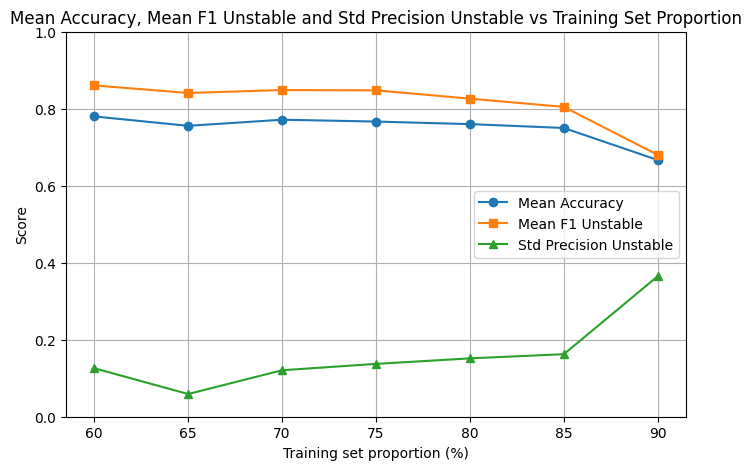

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取结果文件
df = pd.read_csv("./output_marker/lr_train_size_cv_summary.csv")

# 去掉可能的空行
df = df.dropna(subset=[
    "train_percent",
    "mean_accuracy",
    "mean_f1_unstable",
    "std_precision_unstable"
])

# 按训练集比例排序
df = df.sort_values("train_percent")

# 画三折线图
plt.figure(figsize=(8, 5))

plt.plot(
    df["train_percent"],
    df["mean_accuracy"],
    marker="o",
    label="Mean Accuracy"
)

plt.plot(
    df["train_percent"],
    df["mean_f1_unstable"],
    marker="s",
    label="Mean F1 Unstable"
)

plt.plot(
    df["train_percent"],
    df["std_precision_unstable"],
    marker="^",
    label="Std Precision Unstable"
)

# 坐标轴和标题
plt.xlabel("Training set proportion (%)")
plt.ylabel("Score")
plt.title("Mean Accuracy, Mean F1 Unstable and Std Precision Unstable vs Training Set Proportion")

# x轴刻度
plt.xticks(df["train_percent"])

# y轴范围
plt.ylim(0, 1)

# 网格和图例
plt.grid(True)
plt.legend()

# 显示图像
plt.show()

# 折线图---10次求平均

In [ ]:
#####折线图----不同比例的数据来训练
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# =========================
# 1. 读取有标签数据
# =========================
X = pd.read_csv("./output_marker/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output_marker/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 样本顺序一致
X = X.loc[y.index]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

# =========================
# 2. 设置训练比例和交叉验证次数
# =========================
train_sizes = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

# 你可以改成 5 或 10
n_splits = 10

# unstable 判定阈值
threshold = 0.6

random_state = 42

summary_rows = []
all_fold_predictions = []

# =========================
# 3. 对每个训练比例做交叉验证
# =========================
for train_size in train_sizes:
    test_size = 1 - train_size

    print("\n" + "=" * 80)
    print(f"Training size = {int(train_size * 100)}%, Holdout size = {int(test_size * 100)}%")
    print("=" * 80)

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        train_size=train_size,
        test_size=test_size,
        random_state=random_state
    )

    fold_metrics = []

    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # =========================
        # 4. 建模
        # =========================
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                max_iter=1000,
                random_state=random_state
            ))
        ])

        model.fit(X_train, y_train)

        # =========================
        # 5. 预测剩余有标签数据
        # =========================
        prob_unstable = model.predict_proba(X_test)[:, 1]

        y_pred = (prob_unstable >= threshold).astype(int)

        # =========================
        # 6. 计算指标
        # =========================
        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, prob_unstable)
        else:
            auc = np.nan

        fold_metrics.append({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "accuracy": acc,
            "precision_unstable": precision,
            "recall_unstable": recall,
            "f1_unstable": f1,
            "roc_auc": auc
        })

        # =========================
        # 7. 保存每折预测明细
        # =========================
        fold_pred_df = pd.DataFrame({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "sample_id": X_test.index,
            "true_label_numeric": y_test.values,
            "prob_unstable": prob_unstable,
            "pred_label_numeric": y_pred
        })

        fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        def assign_3class(p):
            if p >= 0.8:
                return "high-confidence unstable"
            elif p >= 0.6:
                return "unstable-like"
            else:
                return "non-unstable"

        fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(assign_3class)

        all_fold_predictions.append(fold_pred_df)

        print(f"\nFold {fold_id}")
        print(f"n_train = {len(X_train)}, n_test = {len(X_test)}")
        print(f"Accuracy = {acc:.4f}, AUC = {auc:.4f}, F1 = {f1:.4f}")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

    # =========================
    # 8. 汇总该训练比例的平均表现
    # =========================
    fold_metrics_df = pd.DataFrame(fold_metrics)

    summary_rows.append({
        "train_size": train_size,
        "train_percent": int(train_size * 100),
        "n_splits": n_splits,

        "mean_accuracy": fold_metrics_df["accuracy"].mean(),
        "std_accuracy": fold_metrics_df["accuracy"].std(),

        "mean_precision_unstable": fold_metrics_df["precision_unstable"].mean(),
        "std_precision_unstable": fold_metrics_df["precision_unstable"].std(),

        "mean_recall_unstable": fold_metrics_df["recall_unstable"].mean(),
        "std_recall_unstable": fold_metrics_df["recall_unstable"].std(),

        "mean_f1_unstable": fold_metrics_df["f1_unstable"].mean(),
        "std_f1_unstable": fold_metrics_df["f1_unstable"].std(),

        "mean_roc_auc": fold_metrics_df["roc_auc"].mean(),
        "std_roc_auc": fold_metrics_df["roc_auc"].std()
    })

# =========================
# 9. 保存结果
# =========================
summary_df = pd.DataFrame(summary_rows)
all_predictions_df = pd.concat(all_fold_predictions, axis=0)

summary_df = summary_df.sort_values("train_size")

print("\n" + "=" * 80)
print("Cross-validation summary")
print("=" * 80)
print(summary_df)

summary_df.to_csv(
    "./output_marker/lr_train_size_cv_summary_10.csv",
    index=False
)

all_predictions_df.to_csv(
    "./output_marker/lr_train_size_cv_all_fold_predictions_10.csv",
    index=False
)

print("\nSaved:")
print("./output_marker/lr_train_size_cv_summary_10.csv")
print("./output_marker/lr_train_size_cv_all_fold_predictions_10.csv")

X shape: (23, 87)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

Training size = 60%, Holdout size = 40%

Fold 1
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.5714, F1 = 0.8750
Confusion matrix:
[[1 2]
 [0 7]]

Fold 2
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.6667, F1 = 0.8571
Confusion matrix:
[[2 1]
 [1 6]]

Fold 3
n_train = 13, n_test = 10
Accuracy = 0.9000, AUC = 1.0000, F1 = 0.9231
Confusion matrix:
[[3 0]
 [1 6]]

Fold 4
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 1.0000, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 5
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.7143, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 6
n_train = 13, n_test = 10
Accuracy = 0.6000, AUC = 0.6667, F1 = 0.7500
Confusion matrix:
[[0 3]
 [1 6]]

Fold 7
n_train = 13, n_test = 10
Accuracy = 0.6000, AUC = 0.1905, F1 = 0.7500
Confusion matrix:
[[0 3]
 [1 6]]

Fold 8
n_train = 13, n_test = 10
Accuracy = 0.5000, AUC = 0.5714, F1 = 0.6667
Confusion matr

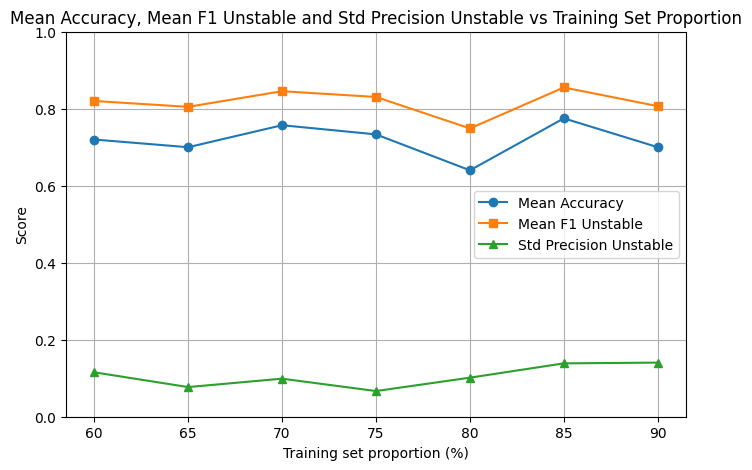

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取结果文件
df = pd.read_csv("./output_marker/lr_train_size_cv_summary_10.csv")

# 去掉可能的空行
df = df.dropna(subset=[
    "train_percent",
    "mean_accuracy",
    "mean_f1_unstable",
    "std_precision_unstable"
])

# 按训练集比例排序
df = df.sort_values("train_percent")

# 画三折线图
plt.figure(figsize=(8, 5))

plt.plot(
    df["train_percent"],
    df["mean_accuracy"],
    marker="o",
    label="Mean Accuracy"
)

plt.plot(
    df["train_percent"],
    df["mean_f1_unstable"],
    marker="s",
    label="Mean F1 Unstable"
)

plt.plot(
    df["train_percent"],
    df["std_precision_unstable"],
    marker="^",
    label="Std Precision Unstable"
)

# 坐标轴和标题
plt.xlabel("Training set proportion (%)")
plt.ylabel("Score")
plt.title("Mean Accuracy, Mean F1 Unstable and Std Precision Unstable vs Training Set Proportion")

# x轴刻度
plt.xticks(df["train_percent"])

# y轴范围
plt.ylim(0, 1)

# 网格和图例
plt.grid(True)
plt.legend()

# 显示图像
plt.show()

# 折线图----100次求平均

In [ ]:
#####折线图----不同比例的数据来训练
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# =========================
# 1. 读取有标签数据
# =========================
X = pd.read_csv("./output_marker/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output_marker/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 样本顺序一致
X = X.loc[y.index]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

# =========================
# 2. 设置训练比例和交叉验证次数
# =========================
train_sizes = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

# 你可以改成 5 或 10
n_splits = 100

# unstable 判定阈值
threshold = 0.6

random_state = 42

summary_rows = []
all_fold_predictions = []

# =========================
# 3. 对每个训练比例做交叉验证
# =========================
for train_size in train_sizes:
    test_size = 1 - train_size

    print("\n" + "=" * 80)
    print(f"Training size = {int(train_size * 100)}%, Holdout size = {int(test_size * 100)}%")
    print("=" * 80)

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        train_size=train_size,
        test_size=test_size,
        random_state=random_state
    )

    fold_metrics = []

    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # =========================
        # 4. 建模
        # =========================
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                max_iter=1000,
                random_state=random_state
            ))
        ])

        model.fit(X_train, y_train)

        # =========================
        # 5. 预测剩余有标签数据
        # =========================
        prob_unstable = model.predict_proba(X_test)[:, 1]

        y_pred = (prob_unstable >= threshold).astype(int)

        # =========================
        # 6. 计算指标
        # =========================
        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, prob_unstable)
        else:
            auc = np.nan

        fold_metrics.append({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "accuracy": acc,
            "precision_unstable": precision,
            "recall_unstable": recall,
            "f1_unstable": f1,
            "roc_auc": auc
        })

        # =========================
        # 7. 保存每折预测明细
        # =========================
        fold_pred_df = pd.DataFrame({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "sample_id": X_test.index,
            "true_label_numeric": y_test.values,
            "prob_unstable": prob_unstable,
            "pred_label_numeric": y_pred
        })

        fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        def assign_3class(p):
            if p >= 0.8:
                return "high-confidence unstable"
            elif p >= 0.6:
                return "unstable-like"
            else:
                return "non-unstable"

        fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(assign_3class)

        all_fold_predictions.append(fold_pred_df)

        print(f"\nFold {fold_id}")
        print(f"n_train = {len(X_train)}, n_test = {len(X_test)}")
        print(f"Accuracy = {acc:.4f}, AUC = {auc:.4f}, F1 = {f1:.4f}")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

    # =========================
    # 8. 汇总该训练比例的平均表现
    # =========================
    fold_metrics_df = pd.DataFrame(fold_metrics)

    summary_rows.append({
        "train_size": train_size,
        "train_percent": int(train_size * 100),
        "n_splits": n_splits,

        "mean_accuracy": fold_metrics_df["accuracy"].mean(),
        "std_accuracy": fold_metrics_df["accuracy"].std(),

        "mean_precision_unstable": fold_metrics_df["precision_unstable"].mean(),
        "std_precision_unstable": fold_metrics_df["precision_unstable"].std(),

        "mean_recall_unstable": fold_metrics_df["recall_unstable"].mean(),
        "std_recall_unstable": fold_metrics_df["recall_unstable"].std(),

        "mean_f1_unstable": fold_metrics_df["f1_unstable"].mean(),
        "std_f1_unstable": fold_metrics_df["f1_unstable"].std(),

        "mean_roc_auc": fold_metrics_df["roc_auc"].mean(),
        "std_roc_auc": fold_metrics_df["roc_auc"].std()
    })

# =========================
# 9. 保存结果
# =========================
summary_df = pd.DataFrame(summary_rows)
all_predictions_df = pd.concat(all_fold_predictions, axis=0)

summary_df = summary_df.sort_values("train_size")

print("\n" + "=" * 80)
print("Cross-validation summary")
print("=" * 80)
print(summary_df)

summary_df.to_csv(
    "./output_marker/lr_train_size_cv_summary_100.csv",
    index=False
)

all_predictions_df.to_csv(
    "./output_marker/lr_train_size_cv_all_fold_predictions_100.csv",
    index=False
)

print("\nSaved:")
print("./output_marker/lr_train_size_cv_summary_100.csv")
print("./output_marker/lr_train_size_cv_all_fold_predictions_100.csv")

X shape: (23, 87)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

Training size = 60%, Holdout size = 40%

Fold 1
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.5714, F1 = 0.8750
Confusion matrix:
[[1 2]
 [0 7]]

Fold 2
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.6667, F1 = 0.8571
Confusion matrix:
[[2 1]
 [1 6]]

Fold 3
n_train = 13, n_test = 10
Accuracy = 0.9000, AUC = 1.0000, F1 = 0.9231
Confusion matrix:
[[3 0]
 [1 6]]

Fold 4
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 1.0000, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 5
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.7143, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 6
n_train = 13, n_test = 10
Accuracy = 0.6000, AUC = 0.6667, F1 = 0.7500
Confusion matrix:
[[0 3]
 [1 6]]

Fold 7
n_train = 13, n_test = 10
Accuracy = 0.6000, AUC = 0.1905, F1 = 0.7500
Confusion matrix:
[[0 3]
 [1 6]]

Fold 8
n_train = 13, n_test = 10
Accuracy = 0.5000, AUC = 0.5714, F1 = 0.6667
Confusion matr

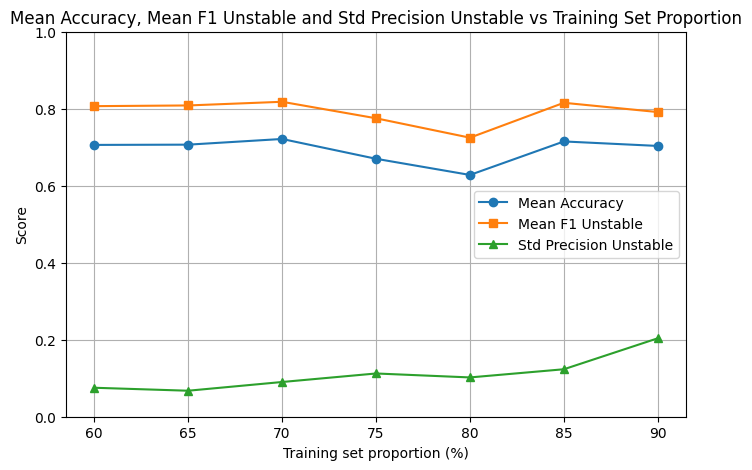

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取结果文件
df = pd.read_csv("./output_marker/lr_train_size_cv_summary_100.csv")

# 去掉可能的空行
df = df.dropna(subset=[
    "train_percent",
    "mean_accuracy",
    "mean_f1_unstable",
    "std_precision_unstable"
])

# 按训练集比例排序
df = df.sort_values("train_percent")

# 画三折线图
plt.figure(figsize=(8, 5))

plt.plot(
    df["train_percent"],
    df["mean_accuracy"],
    marker="o",
    label="Mean Accuracy"
)

plt.plot(
    df["train_percent"],
    df["mean_f1_unstable"],
    marker="s",
    label="Mean F1 Unstable"
)

plt.plot(
    df["train_percent"],
    df["std_precision_unstable"],
    marker="^",
    label="Std Precision Unstable"
)

# 坐标轴和标题
plt.xlabel("Training set proportion (%)")
plt.ylabel("Score")
plt.title("Mean Accuracy, Mean F1 Unstable and Std Precision Unstable vs Training Set Proportion")

# x轴刻度
plt.xticks(df["train_percent"])

# y轴范围
plt.ylim(0, 1)

# 网格和图例
plt.grid(True)
plt.legend()

# 显示图像
plt.show()

# 最终预测新数据 / unknown 样本

上面的交叉验证部分只是为了回答一个问题：**模型在不同训练集比例下稳不稳定**。  
真正要预测新数据时，不再留出测试集，而是：

```text
用所有已知 stable / unstable 样本训练最终模型
        ↓
把待预测样本整理成和训练集完全一样的特征列
        ↓
输出每个 sample 的 unstable 概率和预测类别
```

注意：85% 训练比例是用来评估模型稳定性的，不代表最终预测时只能用 85% 样本。最终预测通常用全部已标注样本训练模型。


### mouse

In [12]:
# ============================================================
# 最终模型训练 + 预测 unknown / 新 h5ad 数据
# ============================================================
# 用法：
# 1. 如果只是预测前面已经从同一个 h5ad 里生成的 unknown 样本：
#       PREDICT_MODE = "existing_unknown"
#
# 2. 如果要预测一个全新的 h5ad 文件：
#       PREDICT_MODE = "new_h5ad"
#       NEW_H5AD_PATH = "/your/path/to/new_data.h5ad"
#
# 前提：
# - 前面的 prepare input cell 已经运行过，已经生成训练特征文件：
#   ./output/X_combined_basic_plus_pseudobulk.csv
#   ./output/y_sample_label_numeric.csv
# - 如果使用 existing_unknown，还需要已经生成：
#   ./output/X_unknown_combined_basic_plus_pseudobulk.csv
# - 如果使用 new_h5ad，新数据里需要有 SAMPLE_COL 和 CELLTYPE_COL 对应的 obs 列。
# ============================================================

import os
import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix

# -------------------------
# 1. 参数设置
# -------------------------
PREDICT_MODE = "new_h5ad"   # 可改成 "new_h5ad"
NEW_H5AD_PATH = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_mouse/scPoli_concat_level3_marker_allmouse.h5ad"  # 只有 PREDICT_MODE = "new_h5ad" 时才需要改这里
OUT_DIR = "./output_marker/mouse"
os.makedirs(OUT_DIR, exist_ok=True)
PRED_THRESHOLD = 0.5        # 判定 unstable-like 的阈值；如果你想更保守，可以改成 0.6
HIGH_CONF_THRESHOLD = 0.8   # 高置信度 unstable 阈值

OUT_X_UNKNOWN_COMBINED = f"{OUT_DIR}/X_unknown_combined_basic_plus_pseudobulk.csv"
FINAL_PRED_OUT = f"{OUT_DIR}/final_prediction_unstable_probability.csv"
FINAL_COEF_OUT = f"{OUT_DIR}/final_lr_feature_coefficients.csv"

SAMPLE_COL = "sample"
# CELLTYPE_COL = "cell_type_level1"
CELLTYPE_COL = "cell_type_level1_corrected"##应该用cell_type_level1_corrected
LABEL_RAW_COL = "Plaque_type"
LABEL_COL = "Plaque_type_clean"

marker_dict = PLAQUE_STABILITY_MARKERS_HUMAN
# -------------------------
# 2. 读取训练特征和标签
# -------------------------
X_train = pd.read_csv("/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type/0531_no_Basophil/output_marker/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y_train = pd.read_csv("/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type/0531_no_Basophil/output_marker/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 顺序一致
X_train = X_train.loc[y_train.index]

print("Training X shape:", X_train.shape)
print("Training y distribution:")
print(y_train.value_counts())

# -------------------------
# 3. 用全部已标注样本训练最终模型
# -------------------------
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

min_class_count = int(y_train.value_counts().min())
if y_train.nunique() == 2 and min_class_count >= 2:
    n_splits = min(5, min_class_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_prob = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    cv_pred = (cv_prob >= PRED_THRESHOLD).astype(int)
    print(f"\nSample-level CV ({n_splits}-fold):")
    print("  ROC-AUC:", round(roc_auc_score(y_train, cv_prob), 3))
    print("  balanced accuracy:", round(balanced_accuracy_score(y_train, cv_pred), 3))
    print("  confusion matrix [[stable, unstable] rows]:")
    print(confusion_matrix(y_train, cv_pred, labels=[0, 1]))
else:
    print("\nSkip CV: each class needs at least 2 samples.")

final_model.fit(X_train, y_train)
print("\nFinal model fitted using all labeled stable / unstable samples.")

# -------------------------
# 4A. 情况一：预测前面已经生成好的 unknown 特征
# -------------------------
if PREDICT_MODE == "existing_unknown":
    X_pred = pd.read_csv(OUT_X_UNKNOWN_COMBINED, index_col=0)
    X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)
    pred_source = "existing_unknown"

# -------------------------
# 4B. 情况二：预测一个新的 h5ad 文件
# -------------------------
elif PREDICT_MODE == "new_h5ad":
    if not os.path.exists(NEW_H5AD_PATH):
        raise FileNotFoundError(
            f"找不到 NEW_H5AD_PATH: {NEW_H5AD_PATH}\n"
            "请把 NEW_H5AD_PATH 改成你的新 h5ad 文件路径。"
        )

    print("\nReading new h5ad...")
    adata_new = sc.read_h5ad(NEW_H5AD_PATH)

    # 和训练数据保持一致：去掉未知 cell type
    if CELLTYPE_COL not in adata_new.obs.columns:
        raise ValueError(f"新数据 adata.obs 里缺少 CELLTYPE_COL: {CELLTYPE_COL}")
    if SAMPLE_COL not in adata_new.obs.columns:
        raise ValueError(f"新数据 adata.obs 里缺少 SAMPLE_COL: {SAMPLE_COL}")

    adata_new = adata_new[adata_new.obs[CELLTYPE_COL] != "unknown"].copy()

    # 如果新数据里也有 original_gene_names，就按你前面训练时的方式改 var_names
    if "original_gene_names" in adata_new.var.columns:
        adata_new.var["original_feature_id"] = adata_new.var_names.astype(str)
        adata_new.var_names = adata_new.var["original_gene_names"].astype(str)
        adata_new.var_names_make_unique()

    adata_new = standardize_gene_names_for_marker_features(adata_new)

    print("New adata shape after filtering unknown cell type:", adata_new.shape)

    # 生成新数据的 cell type proportion 特征
    obs_new = adata_new.obs[[SAMPLE_COL, CELLTYPE_COL]].copy()
    obs_new = obs_new.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])

    cell_count_new = pd.crosstab(obs_new[SAMPLE_COL], obs_new[CELLTYPE_COL])
    cell_prop_new = cell_count_new.div(cell_count_new.sum(axis=1), axis=0)
    cell_prop_new.columns = [f"prop__{c}" for c in cell_prop_new.columns]

    # 读取训练时的 basic / pseudobulk 列，保证新数据列顺序完全一致
    X_basic_train = pd.read_csv("./output_marker/X_basic_celltype_proportion.csv", index_col=0)
    X_pb_train = pd.read_csv("./output_marker/X_pseudobulk_marker.csv", index_col=0)

    X_basic_new = cell_prop_new.reindex(columns=X_basic_train.columns, fill_value=0)

    # 生成新数据的 pseudobulk marker 特征
    X_pb_new = build_pseudobulk_features(
        adata_new,
        marker_dict,
        SAMPLE_COL,
        CELLTYPE_COL
    )
    X_pb_new = X_pb_new.reindex(columns=X_pb_train.columns, fill_value=0)

    # 拼接并对齐到最终训练特征列
    common_new_samples = X_basic_new.index.intersection(X_pb_new.index)
    X_pred = pd.concat([
        X_basic_new.loc[common_new_samples],
        X_pb_new.loc[common_new_samples]
    ], axis=1)

    X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)
    pred_source = "new_h5ad"

else:
    raise ValueError('PREDICT_MODE 只能是 "existing_unknown" 或 "new_h5ad"')

print("\nPrediction X shape:", X_pred.shape)
print("Prediction source:", pred_source)

pb_cols = [c for c in X_pred.columns if c.startswith("pb__")]
zero_pb_cols = [c for c in pb_cols if np.isclose(X_pred[c].sum(), 0)]
if len(zero_pb_cols) > 0:
    print(f"\nWarning: {len(zero_pb_cols)} pseudobulk marker columns are all zero in prediction data.")
    print("First zero columns:", zero_pb_cols[:20])

# -------------------------
# 5. 预测 unstable 概率
# -------------------------
prob_unstable = final_model.predict_proba(X_pred)[:, 1]

pred_df = pd.DataFrame({
    "sample_id": X_pred.index,
    "prob_unstable": prob_unstable
})

# 二分类结果
pred_df[f"pred_label_threshold_{PRED_THRESHOLD}"] = np.where(
    pred_df["prob_unstable"] >= PRED_THRESHOLD,
    "unstable-like",
    "non-unstable"
)

# 三档结果，方便生物学解释
def assign_3class(p):
    if p >= HIGH_CONF_THRESHOLD:
        return "high-confidence unstable"
    elif p >= PRED_THRESHOLD:
        return "unstable-like"
    else:
        return "non-unstable"

pred_df["pred_3class"] = pred_df["prob_unstable"].apply(assign_3class)

# 按 unstable 概率从高到低排序
pred_df = pred_df.sort_values("prob_unstable", ascending=False)

print("\nPrediction result:")
print(pred_df)

pred_df.to_csv(FINAL_PRED_OUT, index=False)
print(f"\nSaved prediction result: {FINAL_PRED_OUT}")

# -------------------------
# 6. 导出 LogisticRegression 特征系数，方便看模型主要依据什么判断 unstable
# -------------------------
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": final_model.named_steps["clf"].coef_[0]
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_df.to_csv(FINAL_COEF_OUT, index=False)
print(f"Saved feature coefficients: {FINAL_COEF_OUT}")

print("\nTop positive features: higher value pushes prediction toward unstable")
print(coef_df.sort_values("coef", ascending=False).head(20))

print("\nTop negative features: higher value pushes prediction toward non-unstable")
print(coef_df.sort_values("coef", ascending=True).head(20))


Training X shape: (23, 87)
Training y distribution:
label
1    16
0     7
Name: count, dtype: int64

Sample-level CV (5-fold):
  ROC-AUC: 0.643
  balanced accuracy: 0.549
  confusion matrix [[stable, unstable] rows]:
[[ 2  5]
 [ 3 13]]

Final model fitted using all labeled stable / unstable samples.

Reading new h5ad...
Mapped 65 mouse-style marker gene names to human symbols for feature alignment.
New adata shape after filtering unknown cell type: (564966, 57692)

===== marker presence check =====
Macrophage:
  present: ['C1QA', 'C1QB', 'CD68', 'AIF1', 'LGALS3', 'CD163', 'APOE', 'LPL', 'TREM2', 'SPP1', 'IL1B', 'TNF', 'CCL2', 'NLRP3', 'MMP9', 'MMP12', 'CTSS', 'CTSK']
  missing: []
Smooth muscle cell:
  present: ['ACTA2', 'MYH11', 'TAGLN', 'CNN1', 'MYOCD', 'COL1A1', 'COL1A2', 'COL3A1', 'ELN', 'DCN', 'LUM', 'VCAN', 'FN1', 'MMP2', 'MGP', 'RUNX2', 'SOX9', 'KLF4', 'SPP1']
  missing: []
Endothelial cell:
  present: ['PECAM1', 'VWF', 'CLDN5', 'CD34', 'EDN1', 'NOS3', 'VCAM1', 'ICAM1', 'SELE', 

In [13]:
adata_new

AnnData object with n_obs × n_vars = 564966 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3'
    var: 'original_gene_names', 'original_feature_id'
    uns: 'cell_type_level1_corrected_colors', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP'

In [14]:
len(adata_new.obs['sample'].value_counts())

122

In [16]:
import pandas as pd

pred_path = "./output_marker/mouse/final_prediction_unstable_probability.csv"
pred = pd.read_csv(pred_path)
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_mouse/scPoli_concat_level3_marker_allmouse.h5ad")
# 只保留需要的列，并改名
pred_sub = pred[[
    "sample_id",
    "pred_label_threshold_0.5",
    "pred_3class"
]].rename(columns={
    "pred_label_threshold_0.5": "Plaque_type_pred",
    "pred_3class": "Plaque_type_pred_3class"
})

# 用 sample_id 映射到 adata.obs
mapping_1 = pred_sub.set_index("sample_id")["Plaque_type_pred"]
mapping_2 = pred_sub.set_index("sample_id")["Plaque_type_pred_3class"]

adata.obs["Plaque_type_pred"] = adata.obs["sample"].map(mapping_1)
adata.obs["Plaque_type_pred_3class"] = adata.obs["sample"].map(mapping_2)

In [17]:
adata.obs['Plaque_type_pred'].value_counts()

Plaque_type_pred
non-unstable     399511
unstable-like    165455
Name: count, dtype: int64

In [18]:
###下一步转换成rds文件
adata.write("./mouse_plaque_type_pred.h5ad")
adata

AnnData object with n_obs × n_vars = 564966 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3', 'Plaque_type_pred', 'Plaque_type_pred_3class'
    var: 'original_gene_names'
    uns: 'cell_type_level1_corrected_colors', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'de

### human

In [22]:
# ============================================================
# 最终模型训练 + 预测 unknown / 新 h5ad 数据
# ============================================================
# 用法：
# 1. 如果只是预测前面已经从同一个 h5ad 里生成的 unknown 样本：
#       PREDICT_MODE = "existing_unknown"
#
# 2. 如果要预测一个全新的 h5ad 文件：
#       PREDICT_MODE = "new_h5ad"
#       NEW_H5AD_PATH = "/your/path/to/new_data.h5ad"
#
# 前提：
# - 前面的 prepare input cell 已经运行过，已经生成训练特征文件：
#   ./output/X_combined_basic_plus_pseudobulk.csv
#   ./output/y_sample_label_numeric.csv
# - 如果使用 existing_unknown，还需要已经生成：
#   ./output/X_unknown_combined_basic_plus_pseudobulk.csv
# - 如果使用 new_h5ad，新数据里需要有 SAMPLE_COL 和 CELLTYPE_COL 对应的 obs 列。
# ============================================================

import os
import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix

# -------------------------
# 1. 参数设置
# -------------------------
PREDICT_MODE = "existing_unknown"   # 可改成 "new_h5ad"
NEW_H5AD_PATH = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_mouse/scPoli_concat_level3_marker_allmouse.h5ad"  # 只有 PREDICT_MODE = "new_h5ad" 时才需要改这里
OUT_DIR = "./output_marker/"
os.makedirs(OUT_DIR, exist_ok=True)
PRED_THRESHOLD = 0.5        # 判定 unstable-like 的阈值；如果你想更保守，可以改成 0.6
HIGH_CONF_THRESHOLD = 0.8   # 高置信度 unstable 阈值

OUT_X_BASIC_UNKNOWN = f"{OUT_DIR}/X_basic_unknown_celltype_proportion.csv"
OUT_X_PB_UNKNOWN = f"{OUT_DIR}/X_pseudobulk_marker_unknown.csv"
OUT_X_UNKNOWN_COMBINED = f"{OUT_DIR}/X_unknown_combined_basic_plus_pseudobulk.csv"
FINAL_PRED_OUT = f"{OUT_DIR}/final_prediction_unstable_probability.csv"
FINAL_COEF_OUT = f"{OUT_DIR}/final_lr_feature_coefficients.csv"

SAMPLE_COL = "sample"
# CELLTYPE_COL = "cell_type_level1"
CELLTYPE_COL = "cell_type_level1_corrected"##应该用cell_type_level1_corrected
LABEL_RAW_COL = "Plaque_type"
LABEL_COL = "Plaque_type_clean"

marker_dict = PLAQUE_STABILITY_MARKERS_HUMAN
# -------------------------
# 2. 读取训练特征和标签
# -------------------------
X_train = pd.read_csv("/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type/0531_no_Basophil/output_marker/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y_train = pd.read_csv("/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type/0531_no_Basophil/output_marker/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 顺序一致
X_train = X_train.loc[y_train.index]

print("Training X shape:", X_train.shape)
print("Training y distribution:")
print(y_train.value_counts())

# -------------------------
# 3. 用全部已标注样本训练最终模型
# -------------------------
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

min_class_count = int(y_train.value_counts().min())
if y_train.nunique() == 2 and min_class_count >= 2:
    n_splits = min(5, min_class_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_prob = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    cv_pred = (cv_prob >= PRED_THRESHOLD).astype(int)
    print(f"\nSample-level CV ({n_splits}-fold):")
    print("  ROC-AUC:", round(roc_auc_score(y_train, cv_prob), 3))
    print("  balanced accuracy:", round(balanced_accuracy_score(y_train, cv_pred), 3))
    print("  confusion matrix [[stable, unstable] rows]:")
    print(confusion_matrix(y_train, cv_pred, labels=[0, 1]))
else:
    print("\nSkip CV: each class needs at least 2 samples.")

final_model.fit(X_train, y_train)
print("\nFinal model fitted using all labeled stable / unstable samples.")

# -------------------------
# 4A. 情况一：预测前面已经生成好的 unknown 特征
# -------------------------
if PREDICT_MODE == "existing_unknown":
    X_pred = pd.read_csv(OUT_X_UNKNOWN_COMBINED, index_col=0)
    X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)
    pred_source = "existing_unknown"

# -------------------------
# 4B. 情况二：预测一个新的 h5ad 文件
# -------------------------
elif PREDICT_MODE == "new_h5ad":
    if not os.path.exists(NEW_H5AD_PATH):
        raise FileNotFoundError(
            f"找不到 NEW_H5AD_PATH: {NEW_H5AD_PATH}\n"
            "请把 NEW_H5AD_PATH 改成你的新 h5ad 文件路径。"
        )

    print("\nReading new h5ad...")
    adata_new = sc.read_h5ad(NEW_H5AD_PATH)

    # 和训练数据保持一致：去掉未知 cell type
    if CELLTYPE_COL not in adata_new.obs.columns:
        raise ValueError(f"新数据 adata.obs 里缺少 CELLTYPE_COL: {CELLTYPE_COL}")
    if SAMPLE_COL not in adata_new.obs.columns:
        raise ValueError(f"新数据 adata.obs 里缺少 SAMPLE_COL: {SAMPLE_COL}")

    adata_new = adata_new[adata_new.obs[CELLTYPE_COL] != "unknown"].copy()

    # 如果新数据里也有 original_gene_names，就按你前面训练时的方式改 var_names
    if "original_gene_names" in adata_new.var.columns:
        adata_new.var["original_feature_id"] = adata_new.var_names.astype(str)
        adata_new.var_names = adata_new.var["original_gene_names"].astype(str)
        adata_new.var_names_make_unique()

    adata_new = standardize_gene_names_for_marker_features(adata_new)

    print("New adata shape after filtering unknown cell type:", adata_new.shape)

    # 生成新数据的 cell type proportion 特征
    obs_new = adata_new.obs[[SAMPLE_COL, CELLTYPE_COL]].copy()
    obs_new = obs_new.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])

    cell_count_new = pd.crosstab(obs_new[SAMPLE_COL], obs_new[CELLTYPE_COL])
    cell_prop_new = cell_count_new.div(cell_count_new.sum(axis=1), axis=0)
    cell_prop_new.columns = [f"prop__{c}" for c in cell_prop_new.columns]

    # 读取训练时的 basic / pseudobulk 列，保证新数据列顺序完全一致
    X_basic_train = pd.read_csv("/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type/0531_no_Basophil/output_marker/X_basic_celltype_proportion.csv", index_col=0)
    X_pb_train = pd.read_csv("/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type/0531_no_Basophil/output_marker/X_pseudobulk_marker.csv", index_col=0)

    X_basic_new = cell_prop_new.reindex(columns=X_basic_train.columns, fill_value=0)

    # 生成新数据的 pseudobulk marker 特征
    X_pb_new = build_pseudobulk_features(
        adata_new,
        marker_dict,
        SAMPLE_COL,
        CELLTYPE_COL
    )
    X_pb_new = X_pb_new.reindex(columns=X_pb_train.columns, fill_value=0)

    # 拼接并对齐到最终训练特征列
    common_new_samples = X_basic_new.index.intersection(X_pb_new.index)
    X_pred = pd.concat([
        X_basic_new.loc[common_new_samples],
        X_pb_new.loc[common_new_samples]
    ], axis=1)

    X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)
    pred_source = "new_h5ad"

else:
    raise ValueError('PREDICT_MODE 只能是 "existing_unknown" 或 "new_h5ad"')

print("\nPrediction X shape:", X_pred.shape)
print("Prediction source:", pred_source)

pb_cols = [c for c in X_pred.columns if c.startswith("pb__")]
zero_pb_cols = [c for c in pb_cols if np.isclose(X_pred[c].sum(), 0)]
if len(zero_pb_cols) > 0:
    print(f"\nWarning: {len(zero_pb_cols)} pseudobulk marker columns are all zero in prediction data.")
    print("First zero columns:", zero_pb_cols[:20])

# -------------------------
# 5. 预测 unstable 概率
# -------------------------
prob_unstable = final_model.predict_proba(X_pred)[:, 1]

pred_df = pd.DataFrame({
    "sample_id": X_pred.index,
    "prob_unstable": prob_unstable
})

# 二分类结果
pred_df[f"pred_label_threshold_{PRED_THRESHOLD}"] = np.where(
    pred_df["prob_unstable"] >= PRED_THRESHOLD,
    "unstable-like",
    "non-unstable"
)

# 三档结果，方便生物学解释
def assign_3class(p):
    if p >= HIGH_CONF_THRESHOLD:
        return "high-confidence unstable"
    elif p >= PRED_THRESHOLD:
        return "unstable-like"
    else:
        return "non-unstable"

pred_df["pred_3class"] = pred_df["prob_unstable"].apply(assign_3class)

# 按 unstable 概率从高到低排序
pred_df = pred_df.sort_values("prob_unstable", ascending=False)

print("\nPrediction result:")
print(pred_df)

pred_df.to_csv(FINAL_PRED_OUT, index=False)
print(f"\nSaved prediction result: {FINAL_PRED_OUT}")

# -------------------------
# 6. 导出 LogisticRegression 特征系数，方便看模型主要依据什么判断 unstable
# -------------------------
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": final_model.named_steps["clf"].coef_[0]
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_df.to_csv(FINAL_COEF_OUT, index=False)
print(f"Saved feature coefficients: {FINAL_COEF_OUT}")

print("\nTop positive features: higher value pushes prediction toward unstable")
print(coef_df.sort_values("coef", ascending=False).head(20))

print("\nTop negative features: higher value pushes prediction toward non-unstable")
print(coef_df.sort_values("coef", ascending=True).head(20))


Training X shape: (23, 87)
Training y distribution:
label
1    16
0     7
Name: count, dtype: int64

Sample-level CV (5-fold):
  ROC-AUC: 0.643
  balanced accuracy: 0.549
  confusion matrix [[stable, unstable] rows]:
[[ 2  5]
 [ 3 13]]

Final model fitted using all labeled stable / unstable samples.

Prediction X shape: (170, 87)
Prediction source: existing_unknown

Prediction result:
        sample_id  prob_unstable pred_label_threshold_0.5  \
48    GSE166676_6   1.000000e+00            unstable-like   
165        TAA_Z3   9.991329e-01            unstable-like   
17    GSE143921_1   9.983792e-01            unstable-like   
115   GSE237230_7   9.980147e-01            unstable-like   
112   GSE237230_4   9.977103e-01            unstable-like   
..            ...            ...                      ...   
134  GSE247238_18   1.605780e-16             non-unstable   
18    GSE143921_2   8.239738e-19             non-unstable   
21    GSE143921_5   3.345597e-21             non-unstable   
19

In [23]:
import pandas as pd

pred_path = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type/0531_no_Basophil/output_marker/final_prediction_unstable_probability.csv"
pred = pd.read_csv(pred_path)
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_allhuman/scPoli_concat_level3_marker_all_metadata.h5ad")
# 只保留需要的列，并改名
pred_sub = pred[[
    "sample_id",
    "pred_label_threshold_0.5",
    "pred_3class"
]].rename(columns={
    "pred_label_threshold_0.5": "Plaque_type_pred",
    "pred_3class": "Plaque_type_pred_3class"
})

# 用 sample_id 映射到 adata.obs
mapping_1 = pred_sub.set_index("sample_id")["Plaque_type_pred"]
mapping_2 = pred_sub.set_index("sample_id")["Plaque_type_pred_3class"]

adata.obs["Plaque_type_pred"] = adata.obs["sample"].map(mapping_1)
adata.obs["Plaque_type_pred_3class"] = adata.obs["sample"].map(mapping_2)

In [24]:
adata.obs['Plaque_type_pred'].value_counts()

Plaque_type_pred
unstable-like    433464
non-unstable     357146
Name: count, dtype: int64

In [25]:
adata.write("/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type/0531_no_Basophil/human_plaque_type_pred.h5ad")

#### 富集分析

用R试一下